# 🚀 Boosting Algorithms (Classification + Regression)


---

## What is Boosting? (The "Study Group" Example)

Unlike Random Forest (where 100 trees act independently like a Board of Directors), Boosting trains models **sequentially**.

Imagine a study group preparing for a final exam:
1. **Student 1 (Tree 1)** takes a practice test and gets a 60%. They missed all the math questions.
2. **Student 2 (Tree 2)** looks at Student 1's results. They *only* study the math questions to fix the mistakes.
3. **Student 3 (Tree 3)** looks at Student 1 & 2's results. They realize the group is still struggling with history, so they *only* study history.

**Boosting is sequential error-correction.** Every new tree focuses exclusively on the mistakes made by the previous ensemble of trees!

## 0) Setup

In [10]:
# Install XGBoost if you don't have it!
!pip install xgboost

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    load_breast_cancer,
    fetch_california_housing,
    make_classification,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)

# ---------------------------------------------------------
# Plotting Aesthetics and Reproducibility
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Setting a global random seed so you get the exact 
# same outputs on your machines.
RSEED = 42
np.random.seed(RSEED)

---
## 1) Boosting for Classification

We’ll use **Breast Cancer Wisconsin (binary classification)** again to compare the different flavors of Boosting.

In [12]:
# Load the dataset directly from scikit-learn as a Pandas DataFrame
bc = load_breast_cancer(as_frame=True)
Xc = bc.data   # Features (cell nucleus measurements)
yc = bc.target # Target (0 = malignant, 1 = benign)

# Splitting the data into 80% Training and 20% Testing.
# We use 'stratify=yc' to ensure the exact same proportion of benign/malignant 
# tumors ends up in both the Train and Test sets.
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=RSEED, stratify=yc
)

print("Train Size:", Xc_train.shape[0], "| Test Size:", Xc_test.shape[0])

Train Size: 455 | Test Size: 114


### 🧠 Think About It
There are 3 main Boosting algorithms in Scikit-Learn: `AdaBoost`, `GradientBoosting`, and `HistGradientBoosting`. How do they differ in how they "fix mistakes"?

### ✅ Answer
1. **AdaBoost (Adaptive Boosting):** It punishes mistakes by increasing the *weight* of rows that it guessed wrong. The next tree pays more attention to the "heavier" rows.
2. **Gradient Boosting:** It calculates the mathematical *residual error* (Actual - Predicted) and trains the next tree to predict the *error itself!* It literally subtracts its mistakes.
3. **HistGradientBoosting:** The modern, lightning-fast version of Gradient Boosting built for enormous datasets (similar to XGBoost or LightGBM).

In [13]:
# ====================================================================
# 1. AdaBoost (Adaptive Boosting)
# ====================================================================
# AdaBoost traditionally uses incredibly simple models called "Stumps".
# A Stump is just a Decision Tree with a max_depth of 1 (a single split!).
stump = DecisionTreeClassifier(max_depth=1, random_state=RSEED)

# We train 250 of these stumps. Each stump focuses heavily on the 
# rows that the *previous* stump got wrong, by artificially increasing those row weights.
# 'learning_rate' shrinks the contribution of each new tree so it doesn't overcorrect.
# Initialize AdaBoost: It will build up to 100 simple trees (stumps) sequentially
ada_clf = AdaBoostClassifier(estimator=stump, n_estimators=250, learning_rate=0.5, random_state=RSEED)

# ====================================================================
# 2. Gradient Boosting (The Classic)
# ====================================================================
# Instead of changing row weights, Gradient Boosting calculates the actual 
# mathematical error (Residual = Actual - Predicted). 
# The next tree is then trained purely to predict that residual error!
gb_clf = GradientBoostingClassifier(
    n_estimators=300,       # 300 sequential trees acting together
    learning_rate=0.05,     # Small steps forward (usually 0.01 - 0.1)
    max_depth=2,            # Keep trees simple (usually depth 2-5)
    random_state=RSEED
)

# ====================================================================
# 3. Histogram-Based Gradient Boosting (The Speed Demon)
# ====================================================================
# Works exactly like Gradient Boosting, but bins the data into histograms first.
# This makes it ridiculously fast on large datasets (the scikit-learn version of XGBoost).
hgb_clf = HistGradientBoostingClassifier(
    learning_rate=0.05, 
    max_depth=3, 
    max_iter=600,           # Same concept as n_estimators
    early_stopping=True,    # Automatically stops adding trees if the validation score stops improving!
    random_state=RSEED
)

# Store them in a dictionary so we can loop over them easily
models_clf = {
    "1. AdaBoost": ada_clf,
    "2. GradientBoosting": gb_clf,
    "3. HistGradientBoosting": hgb_clf,
}

# Train and Evaluate each model sequentially
for name, m in models_clf.items():
    m.fit(Xc_train, yc_train)           # Instruct the model to learn
    y_pred = m.predict(Xc_test)         # Hard predictions (0 or 1)
    
    # Get probability values (AUC needs probabilities, not hard 0/1 predictions)
    y_score = m.predict_proba(Xc_test)[:, 1] if hasattr(m, "predict_proba") else m.decision_function(Xc_test)
    
    print(f"{name:>24} | Acc: {accuracy_score(yc_test, y_pred):.4f} | AUC: {roc_auc_score(yc_test, y_score):.4f}")

             1. AdaBoost | Acc: 0.9649 | AUC: 0.9841
     2. GradientBoosting | Acc: 0.9474 | AUC: 0.9907
 3. HistGradientBoosting | Acc: 0.9649 | AUC: 0.9911


---
## 1.1 Visualizing the Learning Process (The "Staged" Plot)

Because boosting adds trees sequentially, we can actually watch the model get "smarter" as more trees are added!

With `GradientBoostingClassifier`, we can look at `staged_predict_proba` to see the accuracy at Tree #1, Tree #2, all the way to Tree #300.

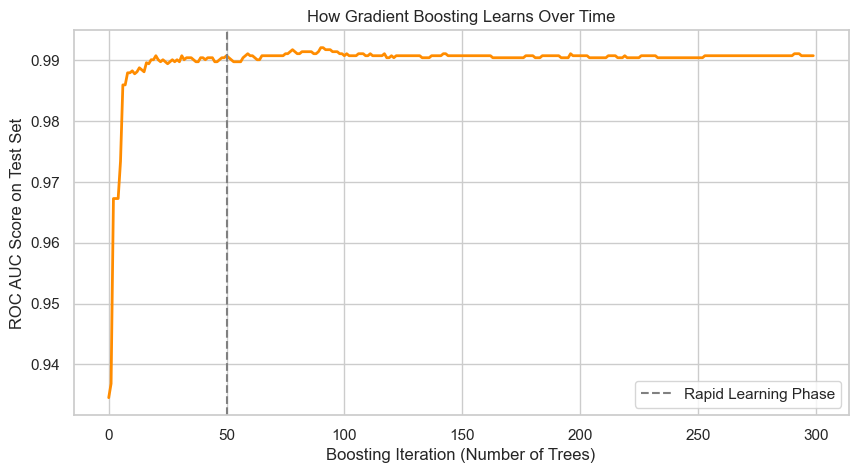

In [14]:
aucs = []

# The 'staged_predict_proba' method yields predictions after EACH individual tree is added.
# This lets us perfectly trace the learning curve!
for proba in gb_clf.staged_predict_proba(Xc_test):
    # Calculate the AUC score at that exact moment in the sequence
    aucs.append(roc_auc_score(yc_test, proba[:, 1]))

plt.figure(figsize=(10, 5))
plt.plot(aucs, color='darkorange', linewidth=2)
plt.xlabel("Boosting Iteration (Number of Trees)")
plt.ylabel("ROC AUC Score on Test Set")
plt.title("How Gradient Boosting Learns Over Time")
plt.axvline(x=50, color='grey', linestyle='--', label='Rapid Learning Phase')
plt.legend()
plt.show()

### 🧠 Think About It

**Q:** Look at the plot above. What happens if we set `learning_rate` to a very small number like 0.001? 
 
### ✅ Answer

The model will take *much* smaller steps towards the correct answer. Therefore, we will need **way more trees** (`n_estimators`) to reach the peak! 

**Golden Rule of Boosting:** If you lower the learning rate, you must increase the number of trees.

---
## 2) Boosting for Regression

Let's test this on the California Housing dataset to predict continuous house prices.
The exact same concept applies! The trees sequentially subtract out the pricing errors.

In [15]:
try:
    housing = fetch_california_housing(as_frame=True)
    Xr, yr = housing.data, housing.target
    print("Loaded California Housing Dataset")
except:
    # Fallback in case there is no internet connection for sklearn downloads
    from sklearn.datasets import load_diabetes
    diab = load_diabetes(as_frame=True)
    Xr, yr = diab.data, diab.target
    print("Loaded Diabetes Fallback Dataset")

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=RSEED
)

Loaded California Housing Dataset


In [16]:
gb_reg = GradientBoostingRegressor(
    n_estimators=600,       # 600 trees sequentially correcting errors
    learning_rate=0.05,     # How heavily to weigh each new tree's correction (5%)
    max_depth=3,            # Depth of the base trees
    random_state=RSEED
)

gb_reg.fit(Xr_train, yr_train)
yr_pred = gb_reg.predict(Xr_test)

print("RMSE:", round(mean_squared_error(yr_test, yr_pred), 4))
print("R-Squared (R2):", round(r2_score(yr_test, yr_pred), 4))

RMSE: 0.2461
R-Squared (R2): 0.8122


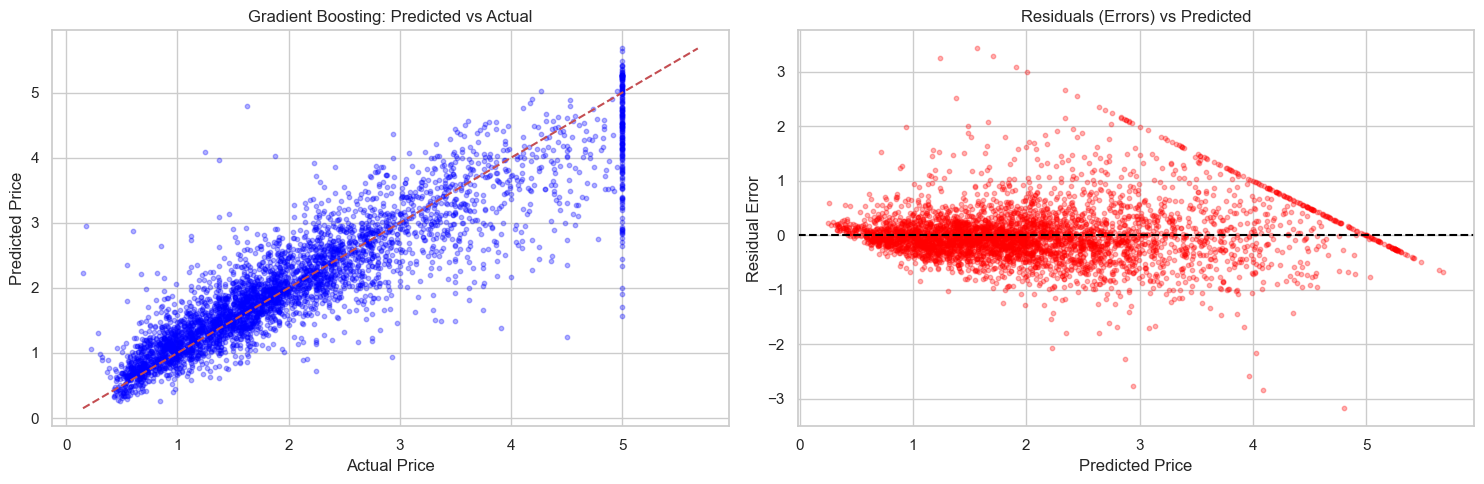

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: How well did our predictions match reality?
# The closer the blue dots to the red dotted line, the more perfect the model.
# Plot 1: Points should hug the diagonal red line for a perfect model
ax1.scatter(yr_test, yr_pred, s=10, alpha=0.3, color='blue')
lims = [min(yr_test.min(), yr_pred.min()), max(yr_test.max(), yr_pred.max())]
ax1.plot(lims, lims, "r--")
ax1.set_title("Gradient Boosting: Predicted vs Actual")
ax1.set_xlabel("Actual Price")
ax1.set_ylabel("Predicted Price")

# Plot 2: Are the errors totally random? (Which is good!)
# If we see a pattern in this residual plot, the algorithm failed to learn something.
resid = yr_test - yr_pred
ax2.scatter(yr_pred, resid, s=10, alpha=0.3, color='red')
ax2.axhline(0, color="black", linestyle="--")
ax2.set_title("Residuals (Errors) vs Predicted")
ax2.set_xlabel("Predicted Price")
ax2.set_ylabel("Residual Error")

plt.tight_layout()
plt.show()

### 📊 Understanding the Gradient Boosting Results

**1. How to Read the Graphs:**
* **Left Graph (Predicted vs Actual):** Compares the real house price (horizontal axis) with what our Gradient Boosting model guessed (vertical axis). The red dashed line represents a "perfect" prediction.
* **Right Graph (Residuals):** Shows the *errors* (real price minus guessed price). The black dashed zero-line means no error at all.

**2. Inference (What does it mean?):**
* In the **left graph**, the blue dots roughly follow the red dashed line, meaning our model's guesses are moving in the right direction. It's doing a decent job finding the true price!
* In the **right graph**, you want the red dots to be a random "cloud" around the zero-line. However, if the dots cluster or form a specific shape (like a cone getting wider on the right), it means the model struggles more when prices get very high.

**3. Final Result:**
* Gradient Boosting sequentially fixes its own mistakes. While this graph isn't 100% perfect, the sequential learning (fitting trees to the previous errors) produced a strong predictive model for housing prices!

---
## 3) XGBoost for Regression (The Industry Favorite)

Let's try the same regression task with XGBoost, the most famous boosting library in the world. It works on the exact same principles as Gradient Boosting but is heavily optimized for speed and performance.

In [19]:
import xgboost as xgb

# Initialize XGBoost: Highly optimized, fast, and handles missing data automatically
xgb_reg = xgb.XGBRegressor(
    n_estimators=600,       # 600 trees sequentially correcting errors
    learning_rate=0.05,     # How heavily to weigh each new tree's correction (5%)
    max_depth=3,            # Depth of the base trees
    random_state=RSEED
)

xgb_reg.fit(Xr_train, yr_train)
yr_pred_xgb = xgb_reg.predict(Xr_test)

print("XGBoost RMSE:", round(mean_squared_error(yr_test, yr_pred_xgb), 4))
print("XGBoost R-Squared (R2):", round(r2_score(yr_test, yr_pred_xgb), 4))

XGBoost RMSE: 0.2459
XGBoost R-Squared (R2): 0.8124


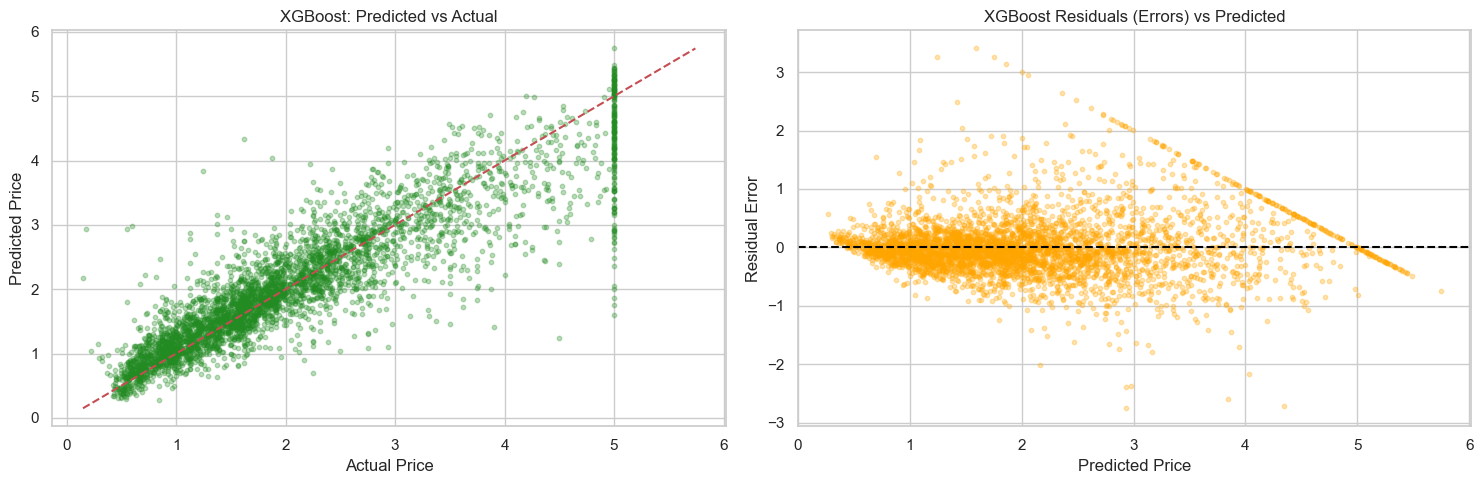

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Points should hug the diagonal red line for a perfect model
ax1.scatter(yr_test, yr_pred_xgb, s=10, alpha=0.3, color='forestgreen')
lims = [min(yr_test.min(), yr_pred_xgb.min()), max(yr_test.max(), yr_pred_xgb.max())]
ax1.plot(lims, lims, "r--")
ax1.set_title("XGBoost: Predicted vs Actual")
ax1.set_xlabel("Actual Price")
ax1.set_ylabel("Predicted Price")

# Plot 2: Points should be a random cloud around the red zero-line
resid_xgb = yr_test - yr_pred_xgb
ax2.scatter(yr_pred_xgb, resid_xgb, s=10, alpha=0.3, color='orange')
ax2.axhline(0, color="black", linestyle="--")
ax2.set_title("XGBoost Residuals (Errors) vs Predicted")
ax2.set_xlabel("Predicted Price")
ax2.set_ylabel("Residual Error")

plt.tight_layout()
plt.show()

### 📊 Understanding the XGBoost Results

**1. How to Read the Graphs:**
* **Left Graph (Predicted vs Actual):** Compares the real house price with what XGBoost guessed. The closer the green dots are to the red dashed line, the better the prediction. 
* **Right Graph (Residuals):** Shows the *errors* (real price minus guessed price). The black dashed zero-line means a perfect prediction (\$0 off).

**2. Inference (What does it mean?):**
* Look at the **left graph**: The green dots should tightly follow the diagonal red line. XGBoost is usually highly accurate and very fast!
* Look at the **right graph**: We want to see a random "cloud" of orange dots around the zero-line. If you notice a cone shape (where errors get larger as the price goes up), it means the model struggles to predict extremely expensive houses accurately.

**3. Final Result:**
* XGBoost essentially does the same thing as Gradient Boosting (correcting errors sequentially), but it uses advanced system optimization and algorithmic enhancements under the hood to run much faster and often yield slightly better accuracy.

---
## 3) Permutation Feature Importance

Because `HistGradientBoosting` doesn't support the built-in impurity metrics, we use **Permutation Importance**. 
We literally shuffle a column (like `MedInc`) to garbage, and see how much the R-squared score crashes. The harder the crash, the more important the feature.

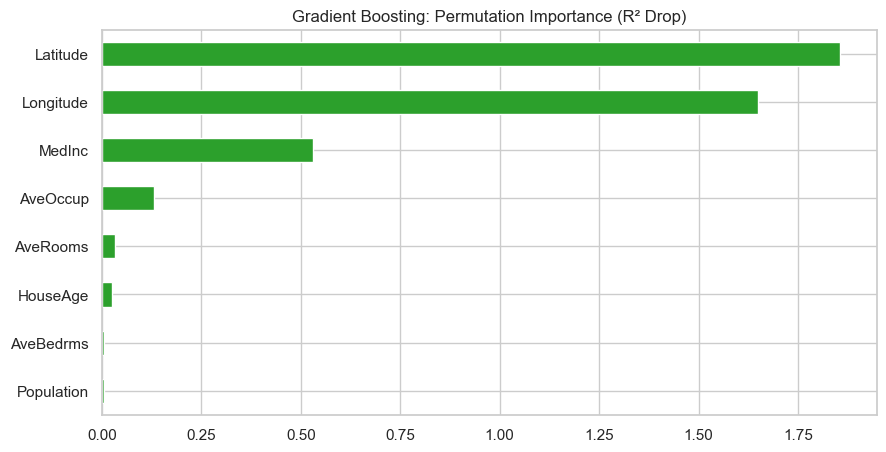

In [21]:
# 'n_repeats=5' means we scramble each feature 5 different times and take the average crash
perm = permutation_importance(
    gb_reg, Xr_test, yr_test, n_repeats=5, random_state=RSEED, n_jobs=-1, scoring="r2"
)

imp = pd.Series(perm.importances_mean, index=Xr.columns, name="R2 Drop")
imp.sort_values(ascending=False).head(8)[::-1].plot(kind="barh", color="#2ca02c")
plt.title("Gradient Boosting: Permutation Importance (R² Drop)")
plt.show()